In [1]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, _tree
from xgboost import XGBClassifier, XGBRegressor


PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系統找不到指定的檔案。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 1538

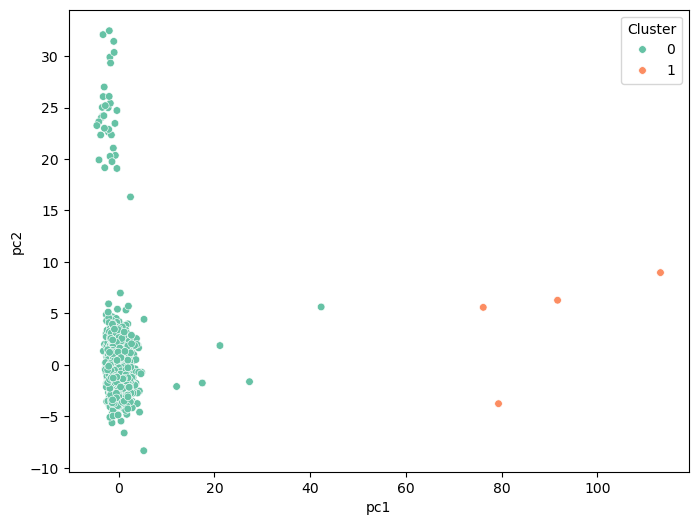

In [2]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

---
---

In [3]:
def local_surrogate(
    x0,
    blackbox_model,
    scaler=None,
    n_samples=500,
    sigma=0.5,
    surrogate_type=None,
    random_state=None,
):
    """
    x0: 1D array-like, 原始特徵空間中的設計點
    blackbox_model: 已訓練好的黑箱模型, 需有 predict_proba 或 predict
    scaler: 已 fit 好的標準化物件 (如 StandardScaler). 若 None 則不做 scaling
    n_samples: 在 x0 鄰域內要產生的設計點數 M
    sigma: 在「標準化空間」中的擾動標準差
    surrogate_type: "linear", "tree", "xgb"
    """
    rng = np.random.default_rng(random_state)

    # 1) x0 -> 標準化空間
    x0 = np.asarray(x0).reshape(1, -1)
    if scaler is not None:
        x0_scaled = scaler.transform(x0)
    else:
        x0_scaled = x0.copy()

    n_features = x0_scaled.shape[1]

    # 2) 在標準化空間中, 以 N(x0, sigma^2 I) 產生鄰域設計點 Z_scaled
    eps = rng.normal(loc=0.0, scale=sigma, size=(n_samples, n_features))
    Z_scaled = x0_scaled + eps

    # 3) 還原回原始空間 Z (給 surrogate 用的自變數)
    if scaler is not None:
        Z = scaler.inverse_transform(Z_scaled)
    else:
        Z = Z_scaled

    # 4) 用黑箱模型當 oracle 產生 pseudo-label
    if hasattr(blackbox_model, "predict_proba"):
        # 二元分類, 取 class=1 機率當連續目標
        p = blackbox_model.predict_proba(Z)[:, 1]
        y_local = p
    else:
        # 沒有 predict_proba 就直接用 predict 的連續輸出
        y_local = blackbox_model.predict(Z)

    # 5) 在 (Z, y_local) 上 fit 一個 surrogate family
    if surrogate_type == "linear":
        surrogate = LinearRegression()
        
    elif surrogate_type == "tree":
        surrogate = DecisionTreeRegressor(max_depth=6, min_samples_leaf=2, random_state=random_state)

    elif surrogate_type == 'xgb':
        surrogate = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=random_state, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')

    else:
        raise ValueError("surrogate_type must be 'someone'")
    surrogate.fit(Z, y_local)

    # 6) 衡量 surrogate 對黑箱在鄰域的擬合程度
    y_hat_local = surrogate.predict(Z)
    mse = mean_squared_error(y_local, y_hat_local)
    r2 = r2_score(y_local, y_hat_local)

    info = {
        "mse": mse,
        "r2": r2,
        "Z": Z,                     # 鄰域設計點 (原始空間)
        "y_blackbox": y_local,      # 黑箱輸出
        "y_surrogate": y_hat_local  # surrogate 輸出
    }

    return surrogate, info


---
---

依照KMEANS分的cluster=0/1各自去做surrogate

In [8]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

X_smote_df["cluster"] = cluster

# 全資料（SMOTE+標準化空間）依 cluster 分開跑 local surrogate
X_all_df = X_smote_df.drop(columns=["cluster"])
c_all    = X_smote_df["cluster"].to_numpy()

# ---- 建好 X_all_df, c_all 之後，先訓練 blackbox（分群各一個） ----
def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx]
        yc = y_all[idx]

        m = LogisticRegression(max_iter=2000, class_weight="balanced", penalty="l1", solver="liblinear", random_state=42)
        models[c] = m.fit(Xc, yc)
    return models

blackbox = fit_blackbox_per_cluster(X_all_df, y_smote, c_all)

records = []

for c in [0, 1]:
    idx_c = np.where(c_all == c)[0]
    X_c = X_all_df.iloc[idx_c]

    clf_c = blackbox[c]
    p_hat_c = clf_c.predict_proba(X_c)[:, 1]

    for j, i_global in enumerate(idx_c):
        x0 = X_all_df.iloc[i_global].values

        sur_model, info = local_surrogate(
            x0=x0,
            blackbox_model=clf_c,
            scaler=None,
            n_samples=500,
            sigma=0.5,
            surrogate_type="tree",
            random_state=42
        )

        records.append({
            "cluster": int(c),
            "local_R2": float(info["r2"]),
            "local_MSE": float(info["mse"]),
            "p_hat": float(p_hat_c[j]),
            "global_index": int(i_global)
        })

local_df = pd.DataFrame(records)


PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\No\AppData\Local\Temp\ipykernel_6656\525412366.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid f

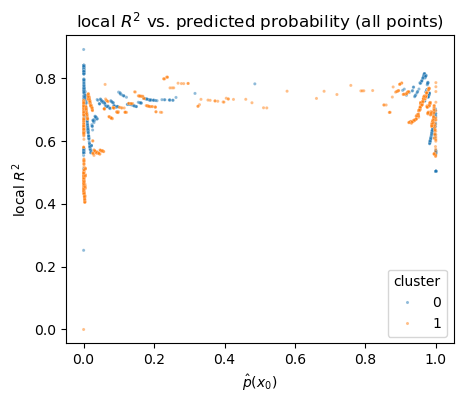

In [9]:
m0 = (local_df["cluster"] == 0)

plt.figure(figsize=(5,4))
sns.scatterplot(x=local_df["p_hat"], y=local_df["local_R2"],
            s=5, alpha=0.5, marker="o", hue=local_df['cluster'])
plt.xlabel(r"$\hat p(x_0)$")
plt.ylabel("local $R^2$")
plt.title("local $R^2$ vs. predicted probability (all points)")
plt.show()


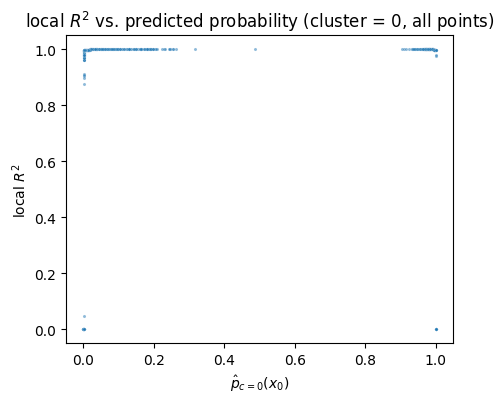

In [32]:
m0 = (local_df["cluster"] == 0)

plt.figure(figsize=(5,4))
sns.scatterplot(x=local_df.loc[m0, "p_hat"], y=local_df.loc[m0, "local_R2"],
            s=5, alpha=0.5, marker="o")
plt.xlabel(r"$\hat p_{c=0}(x_0)$")
plt.ylabel("local $R^2$")
plt.title("local $R^2$ vs. predicted probability (cluster = 0, all points)")
plt.show()


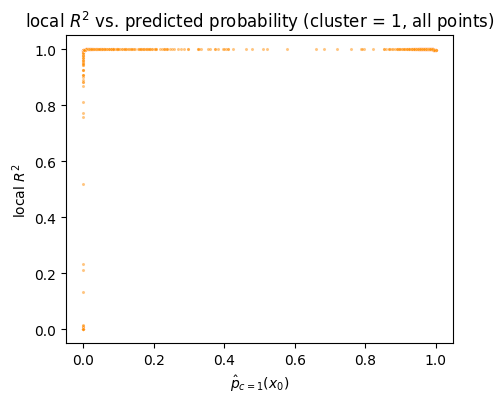

In [33]:
m0 = (local_df["cluster"] == 1)

plt.figure(figsize=(5,4))
sns.scatterplot(x=local_df.loc[m0, "p_hat"], y=local_df.loc[m0, "local_R2"],
            s=5, alpha=0.5, marker="o", color='darkorange')
plt.xlabel(r"$\hat p_{c=1}(x_0)$")
plt.ylabel("local $R^2$")
plt.title("local $R^2$ vs. predicted probability (cluster = 1, all points)")
plt.show()


In [ ]:
local_df[(local_df['cluster']==0)&(local_df['p_hat']>0.35)&(local_df['p_hat']<0.65)]

In [ ]:
local_df[(local_df['cluster']==1)&(local_df['p_hat']>0.35)&(local_df['p_hat']<0.65)]

---
---

In [ ]:
records = []

for i in range(X_test.shape[0]):
    x0 = X_test.iloc[i].values # 設計點 x0，用標準化+SMOTE 後的空間

    sur_model, info = local_surrogate(
        x0=x0,
        blackbox_model=clf,
        scaler=None,
        n_samples=500,
        sigma=0.5,
        surrogate_type="tree",
        random_state=42
    )
    
    records.append({'local_R2':info["r2"],
                    'local_MSE':info["mse"]})

local_df = pd.DataFrame(records)

idx = np.arange(len(X_test))
p_test = clf.predict_proba(X_test)[:, 1]

local_df["p_hat"] = p_test[idx]

plt.figure(figsize=(5,4))
plt.scatter(local_df["p_hat"], local_df["local_R2"], s=5, alpha=0.5)
plt.xlabel(r"$\hat p(x_0)$")
plt.ylabel("local R^2")
plt.title("local R^2 vs. predicted probability")
plt.show()

---
---

In [15]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

X_smote_df["cluster"] = cluster

# 全資料（SMOTE+標準化空間）依 cluster 分開跑 local surrogate
X_all_df = X_smote_df.drop(columns=["cluster"])
c_all    = X_smote_df["cluster"].to_numpy()

# ---- 建好 X_all_df, c_all 之後，先訓練 blackbox（分群各一個） ----
def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx]
        yc = y_all[idx]

        m = XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
        models[c] = m.fit(Xc, yc)
    return models

blackbox = fit_blackbox_per_cluster(X_all_df, y_smote, c_all)

records = []

for c in [0, 1]:
    idx_c = np.where(c_all == c)[0]
    X_c = X_all_df.iloc[idx_c]

    clf_c = blackbox[c]
    p_hat_c = clf_c.predict_proba(X_c)[:, 1]

    for j, i_global in enumerate(idx_c):
        x0 = X_all_df.iloc[i_global].values

        sur_model, info = local_surrogate(
            x0=x0,
            blackbox_model=clf_c,
            scaler=None,
            n_samples=500,
            sigma=0.5,
            surrogate_type="tree",
            random_state=42
        )

        records.append({
            "cluster": int(c),
            "local_R2": float(info["r2"]),
            "local_MSE": float(info["mse"]),
            "p_hat": float(p_hat_c[j]),
            "global_index": int(i_global)
        })

local_df = pd.DataFrame(records)


PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\No\AppData\Local\Temp\ipykernel_6656\1010640699.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


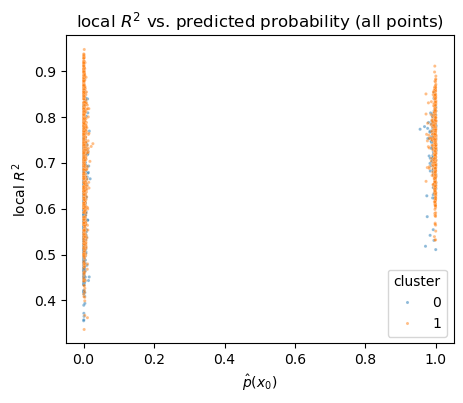

In [16]:
m0 = (local_df["cluster"] == 0)

plt.figure(figsize=(5,4))
sns.scatterplot(x=local_df["p_hat"], y=local_df["local_R2"],
            s=5, alpha=0.5, marker="o", hue=local_df['cluster'])
plt.xlabel(r"$\hat p(x_0)$")
plt.ylabel("local $R^2$")
plt.title("local $R^2$ vs. predicted probability (all points)")
plt.show()
